<a href="https://colab.research.google.com/github/John-Buttell/Credit-Risk-Machine-Learning-Project/blob/main/credit_risk_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 💳 Credit Card Risk Prediction
### ML Project — Midterm Notebook
**Team Members:** xxx1, xxx2

---
## 📋 Notebook Structure
1. **Setup & Imports**
2. **Mount Google Drive & Load Data**
3. **Label Construction** (Good vs Bad clients)
4. **Exploratory Data Analysis (EDA)**
5. **Vintage Analysis**
6. **Preprocessing** (Encoding, Scaling, Train/Val/Test Split)
7. **SMOTE**
8. **Baseline Models** (Logistic Regression & SVM)
9. **Evaluation & Comparison**
10. **Results Summary**

---
> ⚠️ **Shared Workspace Instructions:**
> 1. Upload both CSVs to a shared Google Drive folder (e.g. `MyDrive/ml_project/data/`)
> 2. Share this notebook via Google Drive → right-click → Share
> 3. Both teammates must mount their own Drive (Cell 2.1) — paths will match if you use the same folder structure

---
## 1. 📦 Setup & Imports

In [ ]:
# ── Core libraries ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Scikit-learn: Preprocessing ─────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# ── Scikit-learn: Models ─────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier  # Naive baseline

# ── Scikit-learn: Evaluation ─────────────────────────────────────────────────
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

# ── Reproducibility seed ─────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

# ── Plot style ───────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('✅ All imports successful!')

✅ All imports successful!


---
## 2. 📂 Mount Google Drive & Load Data

**Before running:** Upload your two CSV files to Google Drive at:
```
MyDrive/
└── ml_project/
    └── data/
        ├── application_record.csv
        └── credit_record.csv
```
Both teammates should use this same folder name so the paths below work for everyone.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print('✅ Drive mounted!')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted!


In [ ]:
# ── File paths — edit if your folder structure is different ──────────────────
DATA_DIR = '/content/drive/MyDrive/ml_project/data/'

app_df    = pd.read_csv(DATA_DIR + 'application_record.csv')
credit_df = pd.read_csv(DATA_DIR + 'credit_record.csv')

print(f'application_record shape : {app_df.shape}')
print(f'credit_record shape      : {credit_df.shape}')
print()
app_df.head()

application_record shape : (438557, 18)
credit_record shape      : (1048575, 3)



,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [ ]:
credit_df.head(10)

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C
5,5001712,-1,C
6,5001712,-2,C
7,5001712,-3,C
8,5001712,-4,C
9,5001712,-5,C


---
## 3. 🏷️ Label Construction — Good vs. Bad Clients

**Rule:** A client is labeled **BAD (1)** if they *ever* reached STATUS `'3'`, `'4'`, or `'5'`  
(i.e., 90+ days overdue or written off). All others are **GOOD (0)**.

This mirrors standard industry practice for credit risk labeling.

In [ ]:
# Define the bad statuses (severe delinquency)
BAD_STATUSES = {'3', '4', '5'}

# Flag each record: 1 if that month was a bad status, else 0
credit_df['is_bad'] = credit_df['STATUS'].astype(str).isin(BAD_STATUSES).astype(int)

# Aggregate per client: if ANY month was bad, they are a bad client
labels = credit_df.groupby('ID')['is_bad'].max().reset_index()
labels.columns = ['ID', 'TARGET']   # TARGET: 0 = Good, 1 = Bad

print('Label distribution:')
print(labels['TARGET'].value_counts())
print(f"\nBad rate: {labels['TARGET'].mean()*100:.2f}%")

# ── Merge with application data ───────────────────────────────────────────────
# Only keep applicants that appear in BOTH files
df = app_df.merge(labels, on='ID', how='inner')
print(f'\nMerged dataset shape: {df.shape}')
df.head()

Label distribution:
TARGET
0    45654
1      331
Name: count, dtype: int64

Bad rate: 0.72%

Merged dataset shape: (36457, 19)


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0


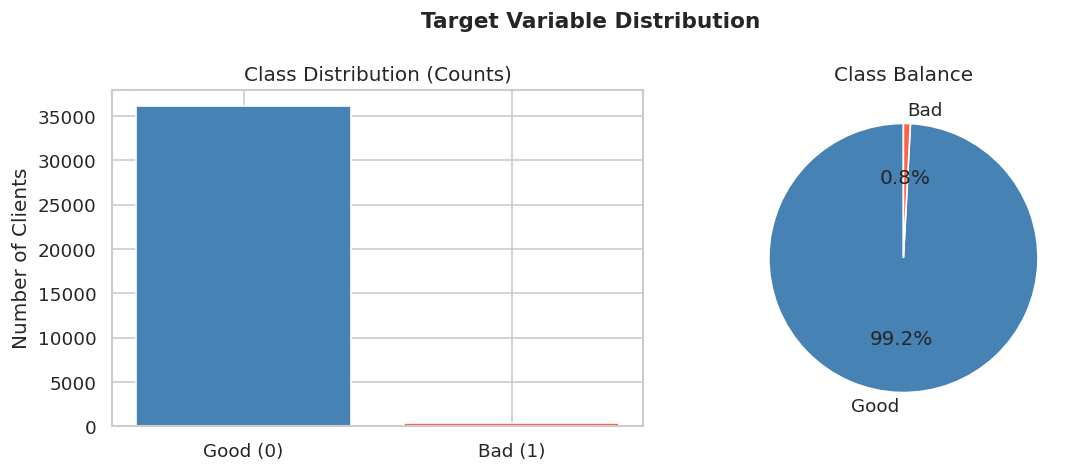

📊 Plot saved to Drive!


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Count plot
counts = df['TARGET'].value_counts()
axes[0].bar(['Good (0)', 'Bad (1)'], counts.values, color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('Class Distribution (Counts)')
axes[0].set_ylabel('Number of Clients')

# Pie chart
axes[1].pie(counts.values, labels=['Good', 'Bad'], autopct='%1.1f%%',
            colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Class Balance')

plt.suptitle('Target Variable Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ml_project/class_balance.png', bbox_inches='tight')
plt.show()
print('📊 Plot saved to Drive!')

---
## 4. 🔍 Exploratory Data Analysis (EDA)

We explore:
- Missing values
- Feature distributions
- Relationships between features and the target label

In [ ]:
# ── Missing values ────────────────────────────────────────────────────────────
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print('Columns with missing values:')
print(missing if len(missing) > 0 else '  None found ✅')
print()
print(df.dtypes)

Columns with missing values:
OCCUPATION_TYPE    11323
dtype: int64

ID                       int64
CODE_GENDER             object
FLAG_OWN_CAR            object
FLAG_OWN_REALTY         object
CNT_CHILDREN             int64
AMT_INCOME_TOTAL       float64
NAME_INCOME_TYPE        object
NAME_EDUCATION_TYPE     object
NAME_FAMILY_STATUS      object
NAME_HOUSING_TYPE       object
DAYS_BIRTH               int64
DAYS_EMPLOYED            int64
FLAG_MOBIL               int64
FLAG_WORK_PHONE          int64
FLAG_PHONE               int64
FLAG_EMAIL               int64
OCCUPATION_TYPE         object
CNT_FAM_MEMBERS        float64
TARGET                   int64
dtype: object


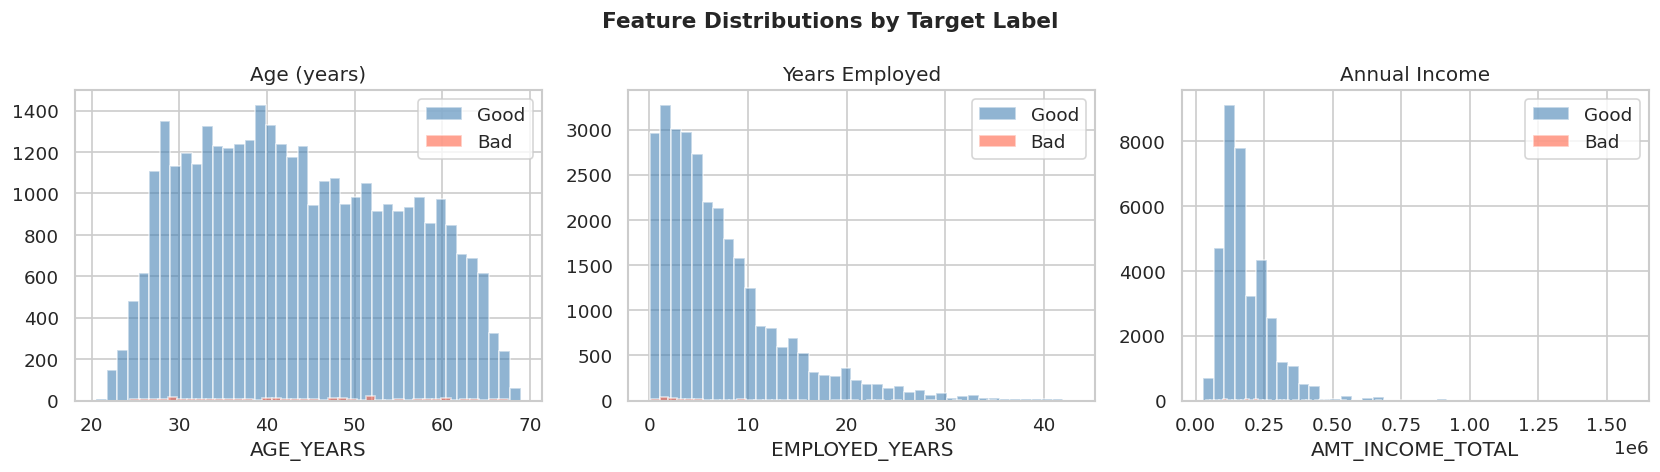

In [ ]:
# DAYS_BIRTH is negative (days before today) — convert to positive age in years
df['AGE_YEARS'] = (-df['DAYS_BIRTH']) / 365

# DAYS_EMPLOYED: positive = currently unemployed; convert employed records to years
df['EMPLOYED_YEARS'] = df['DAYS_EMPLOYED'].apply(lambda x: -x/365 if x < 0 else np.nan)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, title in zip(
    axes,
    ['AGE_YEARS', 'EMPLOYED_YEARS', 'AMT_INCOME_TOTAL'],
    ['Age (years)', 'Years Employed', 'Annual Income']
):
    for label, color in [(0, 'steelblue'), (1, 'tomato')]:
        subset = df[df['TARGET'] == label][col].dropna()
        ax.hist(subset, bins=40, alpha=0.6, color=color,
                label='Good' if label == 0 else 'Bad')
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.legend()

plt.suptitle('Feature Distributions by Target Label', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ml_project/feature_distributions.png', bbox_inches='tight')
plt.show()

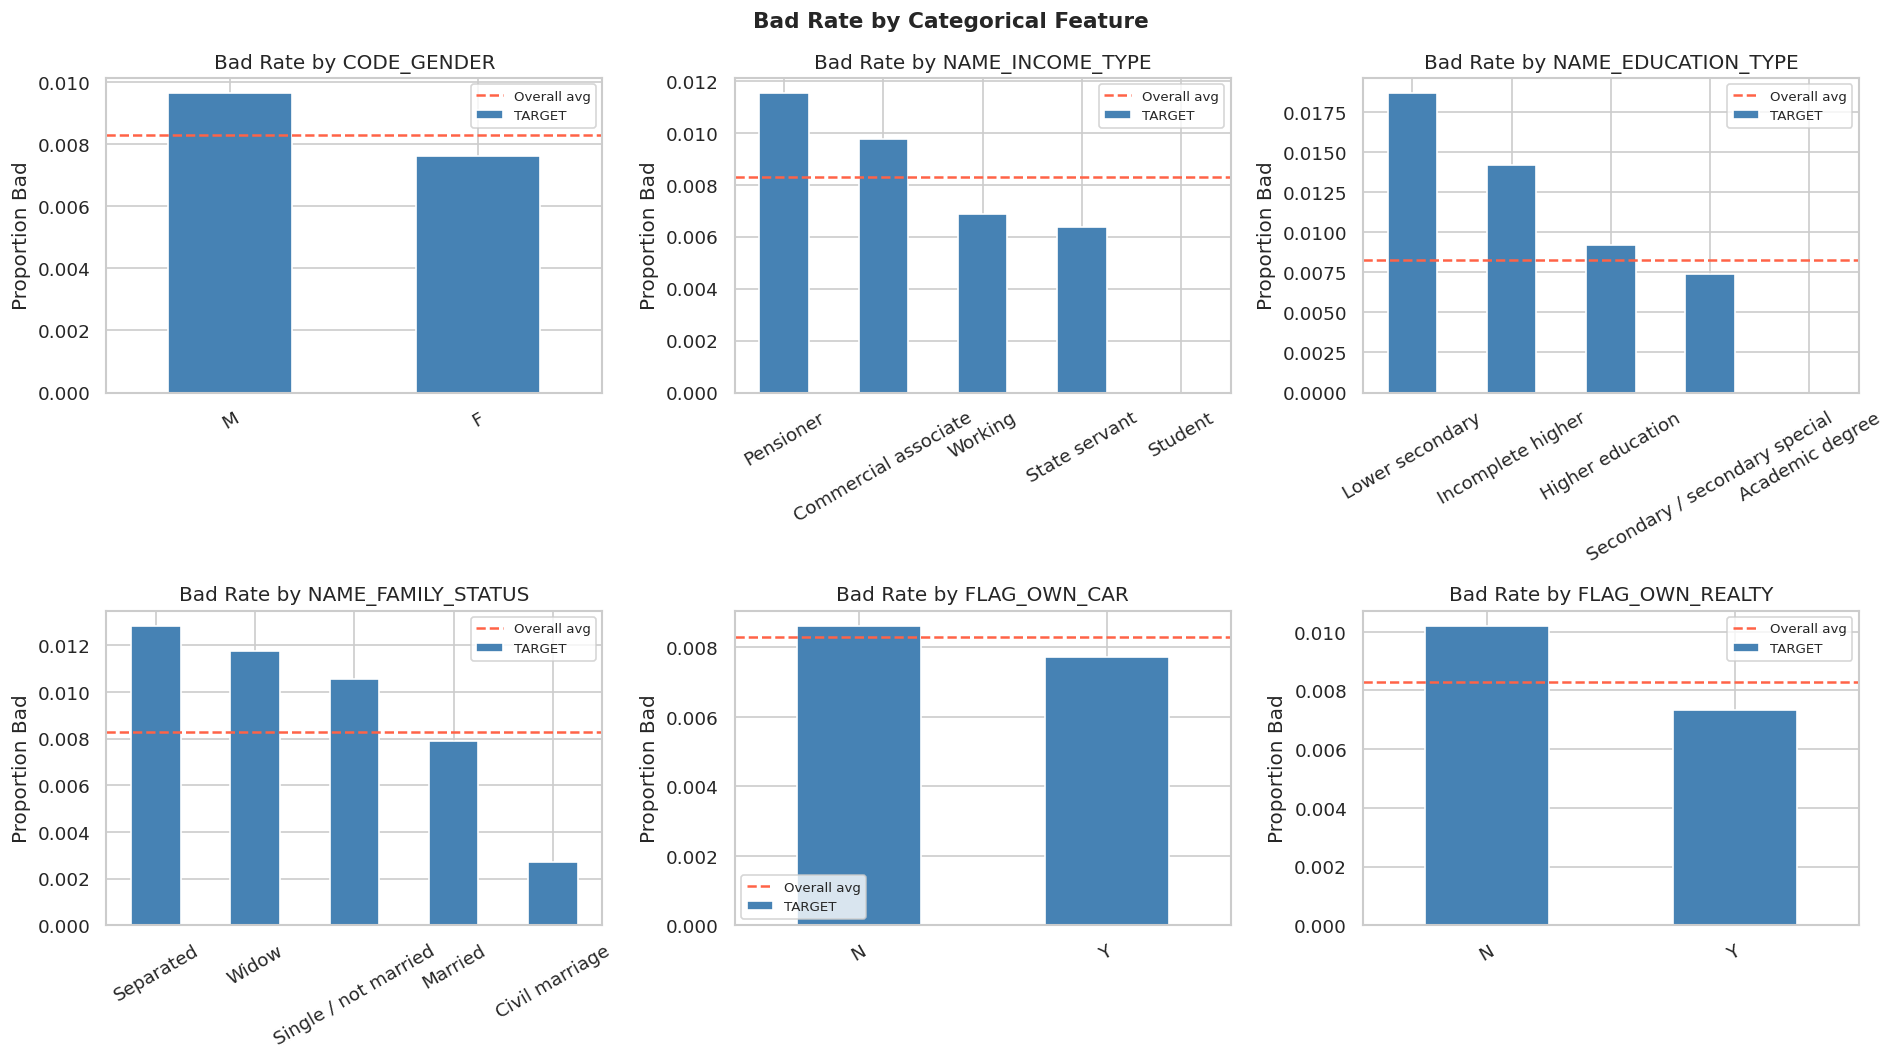

In [ ]:
# ── Categorical features vs Target ───────────────────────────────────────────
cat_cols = ['CODE_GENDER', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
            'NAME_FAMILY_STATUS', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    bad_rates = df.groupby(col)['TARGET'].mean().sort_values(ascending=False)
    bad_rates.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'Bad Rate by {col}')
    ax.set_ylabel('Proportion Bad')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.axhline(df['TARGET'].mean(), color='tomato', linestyle='--', label='Overall avg')
    ax.legend(fontsize=8)

plt.suptitle('Bad Rate by Categorical Feature', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ml_project/categorical_badrates.png', bbox_inches='tight')
plt.show()

---
## 5. 📈 Vintage Analysis

**What is Vintage Analysis?**  
Vintage analysis groups loan accounts by their *origination cohort* — the period when the account was opened — and tracks delinquency rates over time (months-on-book). It answers: *"Do accounts opened in a certain period perform worse than others?"*

**Why it matters for this project:**  
It helps distinguish whether bad behavior is driven by *when* an account was opened (macro-economic conditions, seasonal effects) vs. *who* the applicant is (demographics, income).

In [ ]:
# # ── Build vintage table from credit_record ────────────────────────────────────
# # 'Origination month' = the earliest (most negative) MONTHS_BALANCE for each ID
# # This approximates when the credit account was first opened in our data window

# vintage_df = credit_df.copy()
# vintage_df['is_bad'] = vintage_df['STATUS'].astype(str).isin(BAD_STATUSES).astype(int)

# # Origination cohort: the first month each ID appears in our records
# origination = vintage_df.groupby('ID')['MONTHS_BALANCE'].min().reset_index()
# origination.columns = ['ID', 'ORIGINATION_MONTH']

# vintage_df = vintage_df.merge(origination, on='ID')

# # Months on book = how many months since account first appeared
# vintage_df['MONTHS_ON_BOOK'] = vintage_df['MONTHS_BALANCE'] - vintage_df['ORIGINATION_MONTH']

# # Group into cohorts (e.g., every 6 months)
# vintage_df['COHORT'] = (vintage_df['ORIGINATION_MONTH'] // 6) * 6
# vintage_df['COHORT_LABEL'] = 'Month ' + vintage_df['COHORT'].astype(str)

# # Cumulative bad rate per cohort at each months-on-book
# def cumulative_bad_rate(group):
#     group = group.sort_values('MONTHS_ON_BOOK')
#     group['cum_bad'] = group['is_bad'].cummax()  # once bad, always bad
#     return group

# vintage_df = vintage_df.groupby('ID', group_keys=False).apply(cumulative_bad_rate)

# vintage_table = vintage_df.groupby(['COHORT_LABEL', 'MONTHS_ON_BOOK'])['cum_bad'].mean().reset_index()
# vintage_table.columns = ['Cohort', 'Months_on_Book', 'Cum_Bad_Rate']

# # ── Plot vintage curves ───────────────────────────────────────────────────────
# pivot = vintage_table.pivot(index='Months_on_Book', columns='Cohort', values='Cum_Bad_Rate')

# plt.figure(figsize=(12, 6))
# for col in pivot.columns:
#     plt.plot(pivot.index, pivot[col], marker='o', markersize=3, label=col, linewidth=1.5)

# plt.title('Vintage Analysis — Cumulative Bad Rate by Cohort', fontsize=13, fontweight='bold')
# plt.xlabel('Months on Book')
# plt.ylabel('Cumulative Bad Rate')
# plt.legend(title='Origination Cohort', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
# plt.tight_layout()
# plt.savefig('/content/drive/MyDrive/ml_project/vintage_analysis.png', bbox_inches='tight')
# plt.show()
# print('📊 Vintage plot saved!')

---
## 6. ⚙️ Preprocessing

Steps:
1. Drop ID and raw date columns (not useful as model features)
2. Handle missing values
3. Encode categorical features
4. Train / Validation / Test split (70 / 15 / 15)
5. Standard scale numerical features

In [ ]:
# ── Feature selection ─────────────────────────────────────────────────────────
DROP_COLS = ['ID', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'FLAG_MOBIL']  # + zero-variance feature

model_df = df.drop(columns=DROP_COLS, errors='ignore').copy()

# ── Handle missing values ─────────────────────────────────────────────────────
if 'OCCUPATION_TYPE' in model_df.columns:
    model_df['OCCUPATION_TYPE'] = model_df['OCCUPATION_TYPE'].fillna('Unknown')

model_df['EMPLOYED_YEARS'] = model_df['EMPLOYED_YEARS'].fillna(0)

# ── Encode categorical columns ────────────────────────────────────────────────
cat_features = model_df.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns to encode: {cat_features}')

# Check cardinality to decide encoding strategy
for col in cat_features:
    print(f'  {col}: {model_df[col].nunique()} unique values → {model_df[col].unique().tolist()}')

Categorical columns to encode: ['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE']
  CODE_GENDER: 2 unique values → ['M', 'F']
  FLAG_OWN_CAR: 2 unique values → ['Y', 'N']
  FLAG_OWN_REALTY: 2 unique values → ['Y', 'N']
  NAME_INCOME_TYPE: 5 unique values → ['Working', 'Commercial associate', 'Pensioner', 'State servant', 'Student']
  NAME_EDUCATION_TYPE: 5 unique values → ['Higher education', 'Secondary / secondary special', 'Incomplete higher', 'Lower secondary', 'Academic degree']
  NAME_FAMILY_STATUS: 5 unique values → ['Civil marriage', 'Married', 'Single / not married', 'Separated', 'Widow']
  NAME_HOUSING_TYPE: 6 unique values → ['Rented apartment', 'House / apartment', 'Municipal apartment', 'With parents', 'Co-op apartment', 'Office apartment']
  OCCUPATION_TYPE: 19 unique values → ['Unknown', 'Security staff', 'Sales staff', 'Accountants', 'Laborers', 'Managers', 'Drivers',

In [ ]:
# ── Apply correct encoding per column type ────────────────────────────────────
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Binary columns (2 unique values) → LabelEncoder is fine
binary_cols = [col for col in cat_features if model_df[col].nunique() == 2]

# Nominal columns (no natural order, >2 values) → One-Hot Encode
nominal_cols = [col for col in cat_features if model_df[col].nunique() > 2]

print(f'Binary cols  (LabelEncode) : {binary_cols}')
print(f'Nominal cols (OneHotEncode): {nominal_cols}')

# Label encode binary
le_encoders = {}  # store per-column for inverse transform later
for col in binary_cols:
    le = LabelEncoder()
    model_df[col] = le.fit_transform(model_df[col].astype(str))
    le_encoders[col] = le

# One-hot encode nominal — drop_first avoids multicollinearity
model_df = pd.get_dummies(model_df, columns=nominal_cols, drop_first=True)

# ── Separate features and target ──────────────────────────────────────────────
X = model_df.drop(columns=['TARGET'])
y = model_df['TARGET']

print(f'\nFeature matrix shape : {X.shape}')
print(f'Target distribution  :\n{y.value_counts()}')
print(f'Features used        : {list(X.columns)}')

Binary cols  (LabelEncode) : ['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY']
Nominal cols (OneHotEncode): ['NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE']

Feature matrix shape : (36457, 46)
Target distribution  :
TARGET
0    36155
1      302
Name: count, dtype: int64
Features used        : ['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'AGE_YEARS', 'EMPLOYED_YEARS', 'NAME_INCOME_TYPE_Pensioner', 'NAME_INCOME_TYPE_State servant', 'NAME_INCOME_TYPE_Student', 'NAME_INCOME_TYPE_Working', 'NAME_EDUCATION_TYPE_Higher education', 'NAME_EDUCATION_TYPE_Incomplete higher', 'NAME_EDUCATION_TYPE_Lower secondary', 'NAME_EDUCATION_TYPE_Secondary / secondary special', 'NAME_FAMILY_STATUS_Married', 'NAME_FAMILY_STATUS_Separated', 'NAME_FAMILY_STATUS_Single / not married', 'NAME_FAMILY_STATUS_Widow', 'NAME_HOUSING_TYPE_House / apartment',

In [ ]:
# ── Train / Val / Test split: 70 / 15 / 15 ───────────────────────────────────
# Step 1: split off 30% for val+test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)

# Step 2: split the 30% equally into val and test (15% / 15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f'Train size : {len(X_train):>6}  ({len(X_train)/len(X)*100:.1f}%)')
print(f'Val size   : {len(X_val):>6}  ({len(X_val)/len(X)*100:.1f}%)')
print(f'Test size  : {len(X_test):>6}  ({len(X_test)/len(X)*100:.1f}%)')

# ── Scale features ────────────────────────────────────────────────────────────
# Fit ONLY on training data to avoid data leakage
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print('\n✅ Splits and scaling complete!')

Train size :  25519  (70.0%)
Val size   :   5469  (15.0%)
Test size  :   5469  (15.0%)

✅ Splits and scaling complete!


---
## 7. SMOTE (Synthetic Minority Oversampling Technique)

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy=0.20, random_state=SEED)
X_train_sc, y_train = smote.fit_resample(X_train_sc, y_train)

print('✅ SMOTE applied successfully!')
print(f'New training size: {X_train_sc.shape[0]} samples')

✅ SMOTE applied successfully!
New training size: 30369 samples


---
## 8. 🤖 Model Building

We train three models in order of complexity:

| Model | Purpose |
|---|---|
| **Dummy Classifier** | Naive baseline (always predicts majority class) |
| **Logistic Regression** | Probabilistic linear classifier — interpretable |
| **SVM (RBF kernel)** | Non-linear decision boundary — often stronger |

All models are evaluated on the **validation set** during development.  
Final evaluation uses the **test set** (Section 8), touched only once.

In [ ]:
# ── Evaluation helper ─────────────────────────────────────────────────────────
def evaluate_model(model, X_val, y_val, model_name='Model', threshold=0.44):
    """Print classification report + return key metrics dict."""
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_val)[:, 1]
    else:
        y_prob = model.decision_function(X_val)
        # Normalize decision function scores to [0,1] for AUC
        y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min() + 1e-9)

    y_pred = (y_prob >= threshold).astype(int)
    auc    = roc_auc_score(y_val, y_prob)

    print(f'\n{'='*55}')
    print(f'  {model_name}')
    print(f'{'='*55}')
    print(classification_report(y_val, y_pred, target_names=['Good', 'Bad']))
    print(f'  ROC-AUC : {auc:.4f}')

    return {'model': model_name, 'auc': auc, 'y_prob': y_prob, 'y_pred': y_pred}

results = {}  # Store results for comparison

In [ ]:
# ── Baseline: Dummy Classifier ───────────────────────────────────────────────
dummy = DummyClassifier(strategy='most_frequent', random_state=SEED)
dummy.fit(X_train_sc, y_train)
results['Dummy'] = evaluate_model(dummy, X_val_sc, y_val, 'Naive Baseline (Majority Class)')


  Naive Baseline (Majority Class)
              precision    recall  f1-score   support

        Good       0.99      1.00      1.00      5423
         Bad       0.00      0.00      0.00        46

    accuracy                           0.99      5469
   macro avg       0.50      0.50      0.50      5469
weighted avg       0.98      0.99      0.99      5469

  ROC-AUC : 0.5000


In [ ]:
# --- DIAGNOSTIC CHECK ---
print(f"DEBUG: Training rows: {X_train_sc.shape[0]}")
print(f"DEBUG: Training 'Bad' count: {y_train.sum()}")
# ── Logistic Regression ───────────────────────────────────────────────────────
# class_weight='balanced' helps with class imbalance
lr = LogisticRegression(
    max_iter=1000,
    C=1.0,               # Regularization strength (inverse) — higher = less regularization
    class_weight='balanced',
    random_state=SEED
)
lr.fit(X_train_sc, y_train)
results['LR'] = evaluate_model(lr, X_val_sc, y_val, 'Logistic Regression')

DEBUG: Training rows: 30369
DEBUG: Training 'Bad' count: 5061

  Logistic Regression
              precision    recall  f1-score   support

        Good       0.99      0.50      0.67      5423
         Bad       0.01      0.67      0.02        46

    accuracy                           0.50      5469
   macro avg       0.50      0.59      0.34      5469
weighted avg       0.99      0.50      0.66      5469

  ROC-AUC : 0.5876


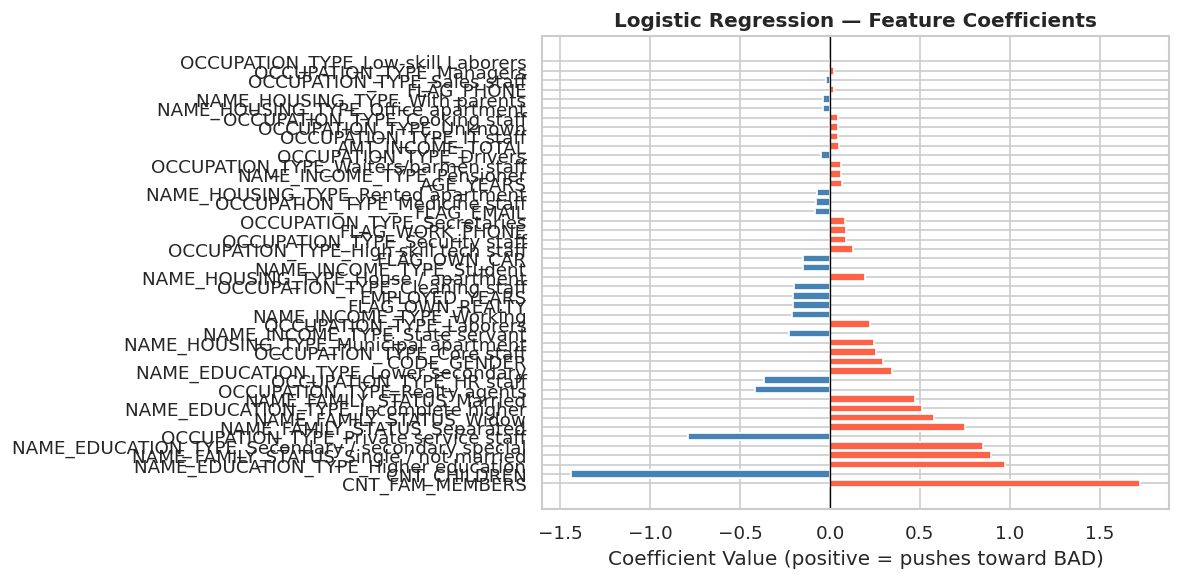

In [ ]:
# ── Logistic Regression: Feature Importance (coefficients) ───────────────────
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

plt.figure(figsize=(10, 5))
colors = ['tomato' if c > 0 else 'steelblue' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Logistic Regression — Feature Coefficients', fontsize=12, fontweight='bold')
plt.xlabel('Coefficient Value (positive = pushes toward BAD)')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ml_project/lr_coefficients.png', bbox_inches='tight')
plt.show()

In [ ]:
# --- DIAGNOSTIC CHECK ---
print(f"DEBUG: Training rows: {X_train_sc.shape[0]}")
print(f"DEBUG: Training 'Bad' count: {y_train.sum()}")
# ── SVM (RBF kernel) ──────────────────────────────────────────────────────────
# NOTE: SVM is slow on large datasets. If runtime is too long, try:
#   - Reducing training data: X_train_sc[:10000], y_train[:10000]
#   - Using kernel='linear' instead of 'rbf'

print('Training SVM... (this may take a few minutes on large datasets)')
svm = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    class_weight='balanced',
    probability=True,   # Needed for predict_proba and AUC
    random_state=SEED
)
svm.fit(X_train_sc, y_train)
results['SVM'] = evaluate_model(svm, X_val_sc, y_val, 'SVM (RBF Kernel)')
print('\n✅ SVM training complete!')

DEBUG: Training rows: 30369
DEBUG: Training 'Bad' count: 5061
Training SVM... (this may take a few minutes on large datasets)

  SVM (RBF Kernel)
              precision    recall  f1-score   support

        Good       0.99      0.97      0.98      5423
         Bad       0.05      0.20      0.07        46

    accuracy                           0.96      5469
   macro avg       0.52      0.58      0.53      5469
weighted avg       0.99      0.96      0.97      5469

  ROC-AUC : 0.6714

✅ SVM training complete!


---
## 9. 📊 Evaluation & Comparison

Compare all models with:
- **ROC curves** side-by-side
- **Confusion matrices**
- **Summary table** ready to paste into your report

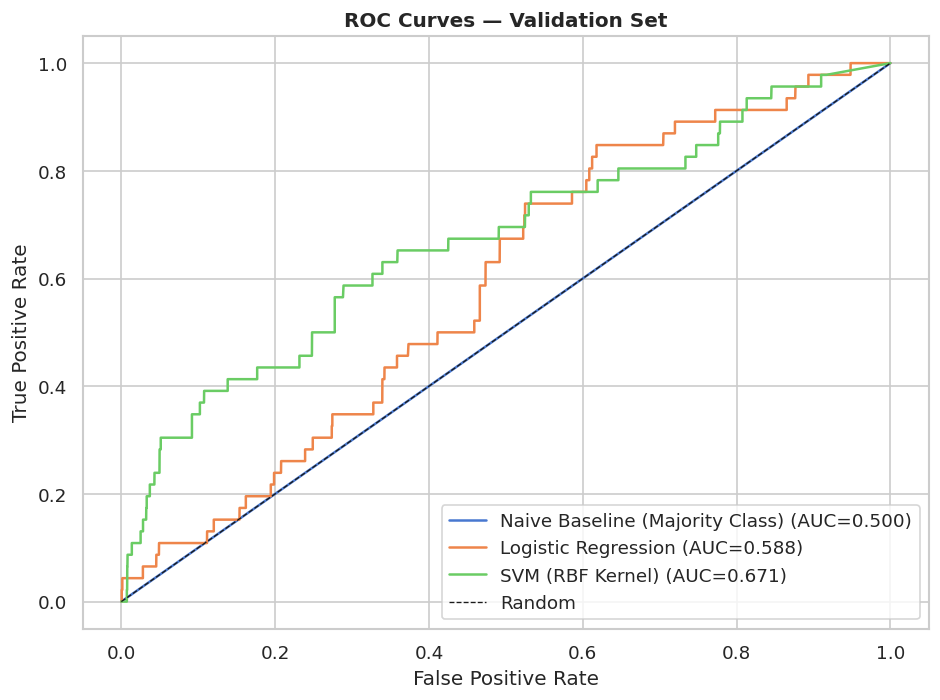

In [ ]:
# ── ROC Curves ───────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 6))

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_val, res['y_prob'])
    plt.plot(fpr, tpr, label=f"{res['model']} (AUC={res['auc']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Validation Set', fontsize=12, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ml_project/roc_curves.png', bbox_inches='tight')
plt.show()

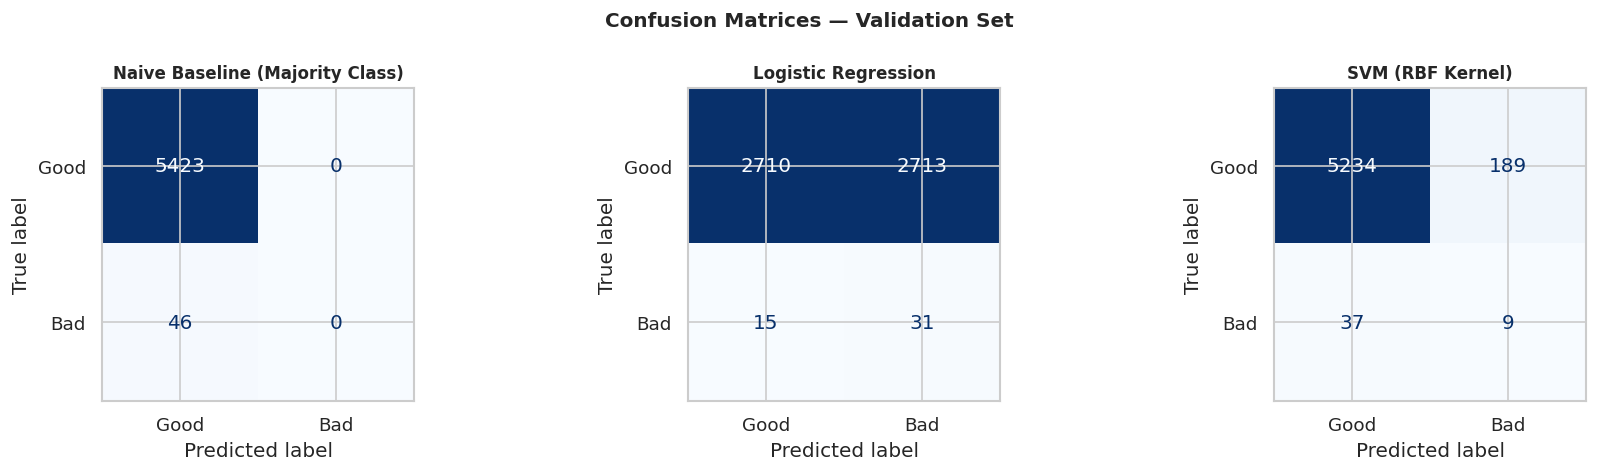

In [ ]:
# ── Confusion Matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_val, res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Good', 'Bad'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(res['model'], fontsize=10, fontweight='bold')

plt.suptitle('Confusion Matrices — Validation Set', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ml_project/confusion_matrices.png', bbox_inches='tight')
plt.show()

In [ ]:
#------- Train Random Forest---------------------
from sklearn.ensemble import RandomForestClassifier

print('Training Random Forest...')
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    max_features='sqrt',
    random_state=SEED,
    n_jobs=-1          # use all CPU cores to speed it up
)
rf.fit(X_train_sc, y_train)
results['RF'] = evaluate_model(rf, X_val_sc, y_val, 'Random Forest')
print('\n✅ Random Forest training complete!')

Training Random Forest...

  Random Forest
              precision    recall  f1-score   support

        Good       0.99      0.99      0.99      5423
         Bad       0.31      0.35      0.33        46

    accuracy                           0.99      5469
   macro avg       0.65      0.67      0.66      5469
weighted avg       0.99      0.99      0.99      5469

  ROC-AUC : 0.7492

✅ Random Forest training complete!


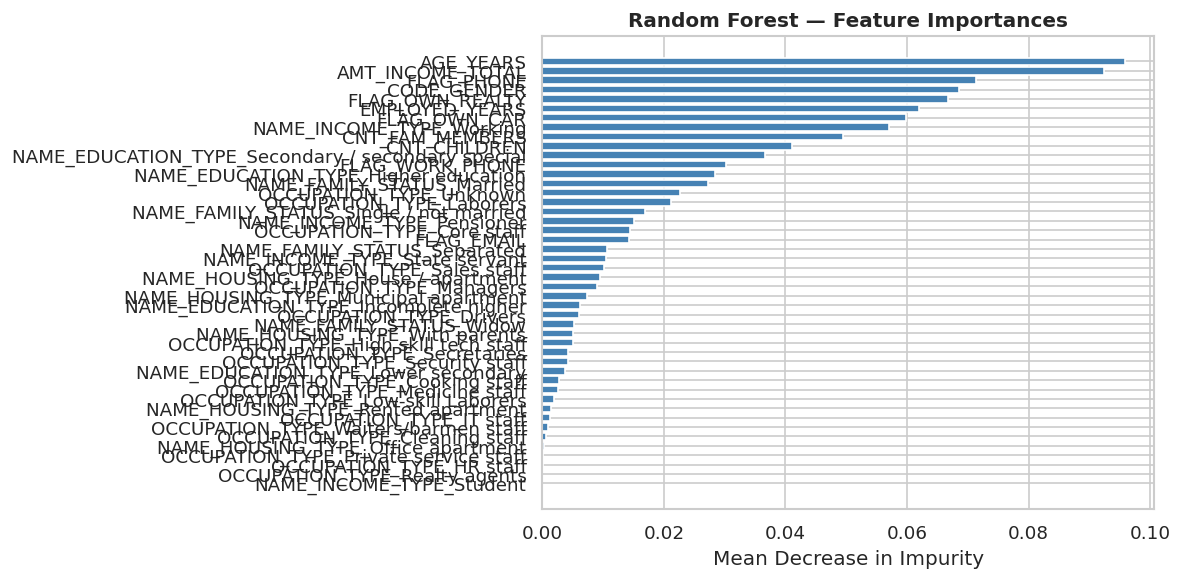

In [ ]:
#-----------Feature Importance Plot----------------

feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(feat_imp['Feature'], feat_imp['Importance'], color='steelblue', edgecolor='white')
plt.title('Random Forest — Feature Importances', fontsize=12, fontweight='bold')
plt.xlabel('Mean Decrease in Impurity')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ml_project/rf_feature_importance.png', bbox_inches='tight')
plt.show()

In [ ]:
#---------------Threshold Tuning for RF--------------
from sklearn.metrics import f1_score as f1

best_thresh, best_f1 = 0.5, 0
y_prob_rf = rf.predict_proba(X_val_sc)[:, 1]

for thresh in np.arange(0.05, 0.95, 0.01):
    preds = (y_prob_rf >= thresh).astype(int)
    score = f1(y_val, preds, zero_division=0)
    if score > best_f1:
        best_f1, best_thresh = score, thresh

print(f'Optimal RF threshold: {best_thresh:.2f}  (F1={best_f1:.4f})')
results['RF_tuned'] = evaluate_model(rf, X_val_sc, y_val,
                                     f'Random Forest (τ={best_thresh:.2f})',
                                     threshold=best_thresh)

Optimal RF threshold: 0.44  (F1=0.3265)

  Random Forest (τ=0.44)
              precision    recall  f1-score   support

        Good       0.99      0.99      0.99      5423
         Bad       0.31      0.35      0.33        46

    accuracy                           0.99      5469
   macro avg       0.65      0.67      0.66      5469
weighted avg       0.99      0.99      0.99      5469

  ROC-AUC : 0.7492


In [ ]:
# ── Summary Table ─────────────────────────────────────────────────────────────
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

rows = []
for name, res in results.items():
    yp = res['y_pred']
    rows.append({
        'Model'    : res['model'],
        'Accuracy' : f"{accuracy_score(y_val, yp):.4f}",
        'Precision': f"{precision_score(y_val, yp, zero_division=0):.4f}",
        'Recall'   : f"{recall_score(y_val, yp, zero_division=0):.4f}",
        'F1'       : f"{f1_score(y_val, yp, zero_division=0):.4f}",
        'ROC-AUC'  : f"{res['auc']:.4f}",
    })

summary_df = pd.DataFrame(rows)
print('📋 Results Summary Table (paste into your midterm report):')
print(summary_df.to_string(index=False))
summary_df

📋 Results Summary Table (paste into your midterm report):
                          Model Accuracy Precision Recall     F1 ROC-AUC
Naive Baseline (Majority Class)   0.9916    0.0000 0.0000 0.0000  0.5000
            Logistic Regression   0.5012    0.0113 0.6739 0.0222  0.5876
               SVM (RBF Kernel)   0.9587    0.0455 0.1957 0.0738  0.6714
                  Random Forest   0.9879    0.3077 0.3478 0.3265  0.7492
         Random Forest (τ=0.44)   0.9879    0.3077 0.3478 0.3265  0.7492


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Naive Baseline (Majority Class),0.9916,0.0000,0.0000,0.0000,0.5000
1,Logistic Regression,0.5012,0.0113,0.6739,0.0222,0.5876
2,SVM (RBF Kernel),0.9587,0.0455,0.1957,0.0738,0.6714
3,Random Forest,0.9879,0.3077,0.3478,0.3265,0.7492
4,Random Forest (τ=0.44),0.9879,0.3077,0.3478,0.3265,0.7492


---
## 10. 🏁 Final Test Set Evaluation

⚠️ **Run this section only once, at the end of your project.**  
The test set is held out until this final evaluation to give an unbiased estimate of real-world performance.

Pick the best model from Section 8 (highest AUC on validation) and evaluate it here.

In [ ]:
# # ── Select best model and run on test set ─────────────────────────────────────
# # Change this to 'SVM' or 'Dummy' depending on your validation results
# BEST_MODEL_KEY = 'LR'   # ← UPDATE after comparing Section 8

# best_model_map = {'Dummy': dummy, 'LR': lr, 'SVM': svm, 'RF' : rf}
# best_model     = best_model_map[BEST_MODEL_KEY]

# print(f'Evaluating best model ({BEST_MODEL_KEY}) on held-out TEST set...')
# test_result = evaluate_model(best_model, X_test_sc, y_test,
#                               f'{BEST_MODEL_KEY} — FINAL TEST SET')

# print('\n✅ Final evaluation complete!')
# print('These are the numbers to report in your midterm report Section 4.')

---
## 📝 Notes & Next Steps

### What to do next (Future Plan → Section 5 of report)
- **Hyperparameter tuning:** Use `GridSearchCV` on `C` and `gamma` for SVM; `C` for LR
- **Class imbalance:** Try `SMOTE` oversampling (`pip install imbalanced-learn`)
- **Feature engineering:** Create ratio features (income per family member, etc.)
- **Additional models:** Random Forest, XGBoost for final report comparison
- **Threshold tuning:** Adjust classification threshold to minimize false negatives (missed bad clients = costly)

### Saving plots for the report
All plots are automatically saved to `MyDrive/ml_project/` and can be inserted directly into your Word/LaTeX report.

### Collaboration tip
Use Colab's built-in commenting (Insert → Comment) to leave notes for your teammate on specific cells.

In [ ]:
from sklearn.model_selection import train_test_split

X_diag_train, _, y_diag_train, _ = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)

df_train = pd.DataFrame(X_diag_train, columns=X.columns)
df_train['TARGET'] = y_diag_train.values

print(f'df_train shape : {df_train.shape}')
print(f'Class counts:\n{df_train["TARGET"].value_counts()}')

df_train shape : (25519, 47)
Class counts:
TARGET
0    25308
1      211
Name: count, dtype: int64


=== Feature Separation (Good vs Bad) ===

                                          feature   good_mean    bad_mean  effect_size  p_value
            NAME_HOUSING_TYPE_Municipal apartment      0.0305      0.0853       0.3168 0.000005
                         NAME_INCOME_TYPE_Working      0.5172      0.4123       0.2099 0.002393
                                  FLAG_OWN_REALTY      0.6713      0.5782       0.1980 0.004188
                                   EMPLOYED_YEARS      6.0179      4.7429       0.1966 0.000509
NAME_EDUCATION_TYPE_Secondary / secondary special      0.6813      0.5972       0.1804 0.009051
              NAME_EDUCATION_TYPE_Lower secondary      0.0102      0.0284       0.1803 0.009112
            NAME_EDUCATION_TYPE_Incomplete higher      0.0383      0.0711       0.1701 0.013888
                       NAME_INCOME_TYPE_Pensioner      0.1693      0.2322       0.1677 0.015290
                     NAME_FAMILY_STATUS_Separated      0.0579      0.0948       0.1574 0.02279

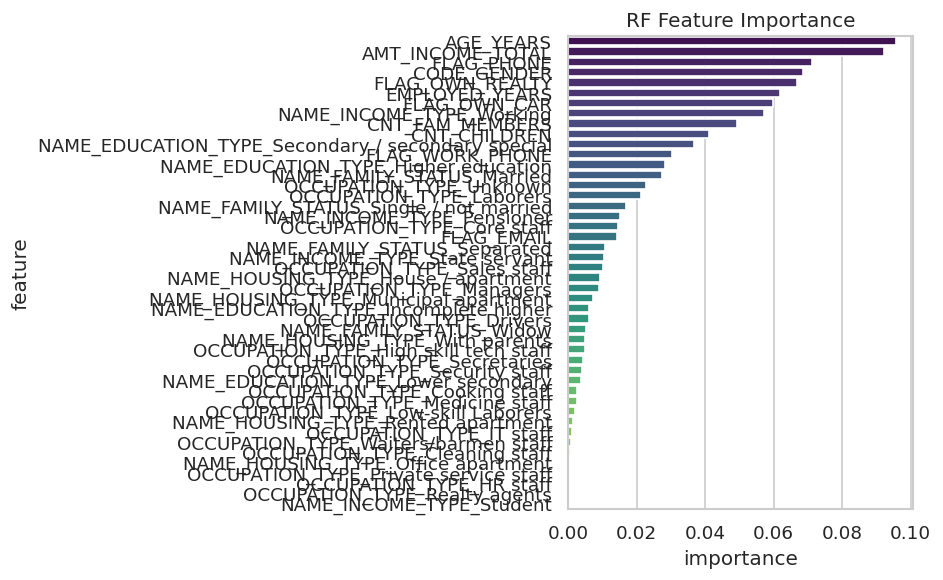

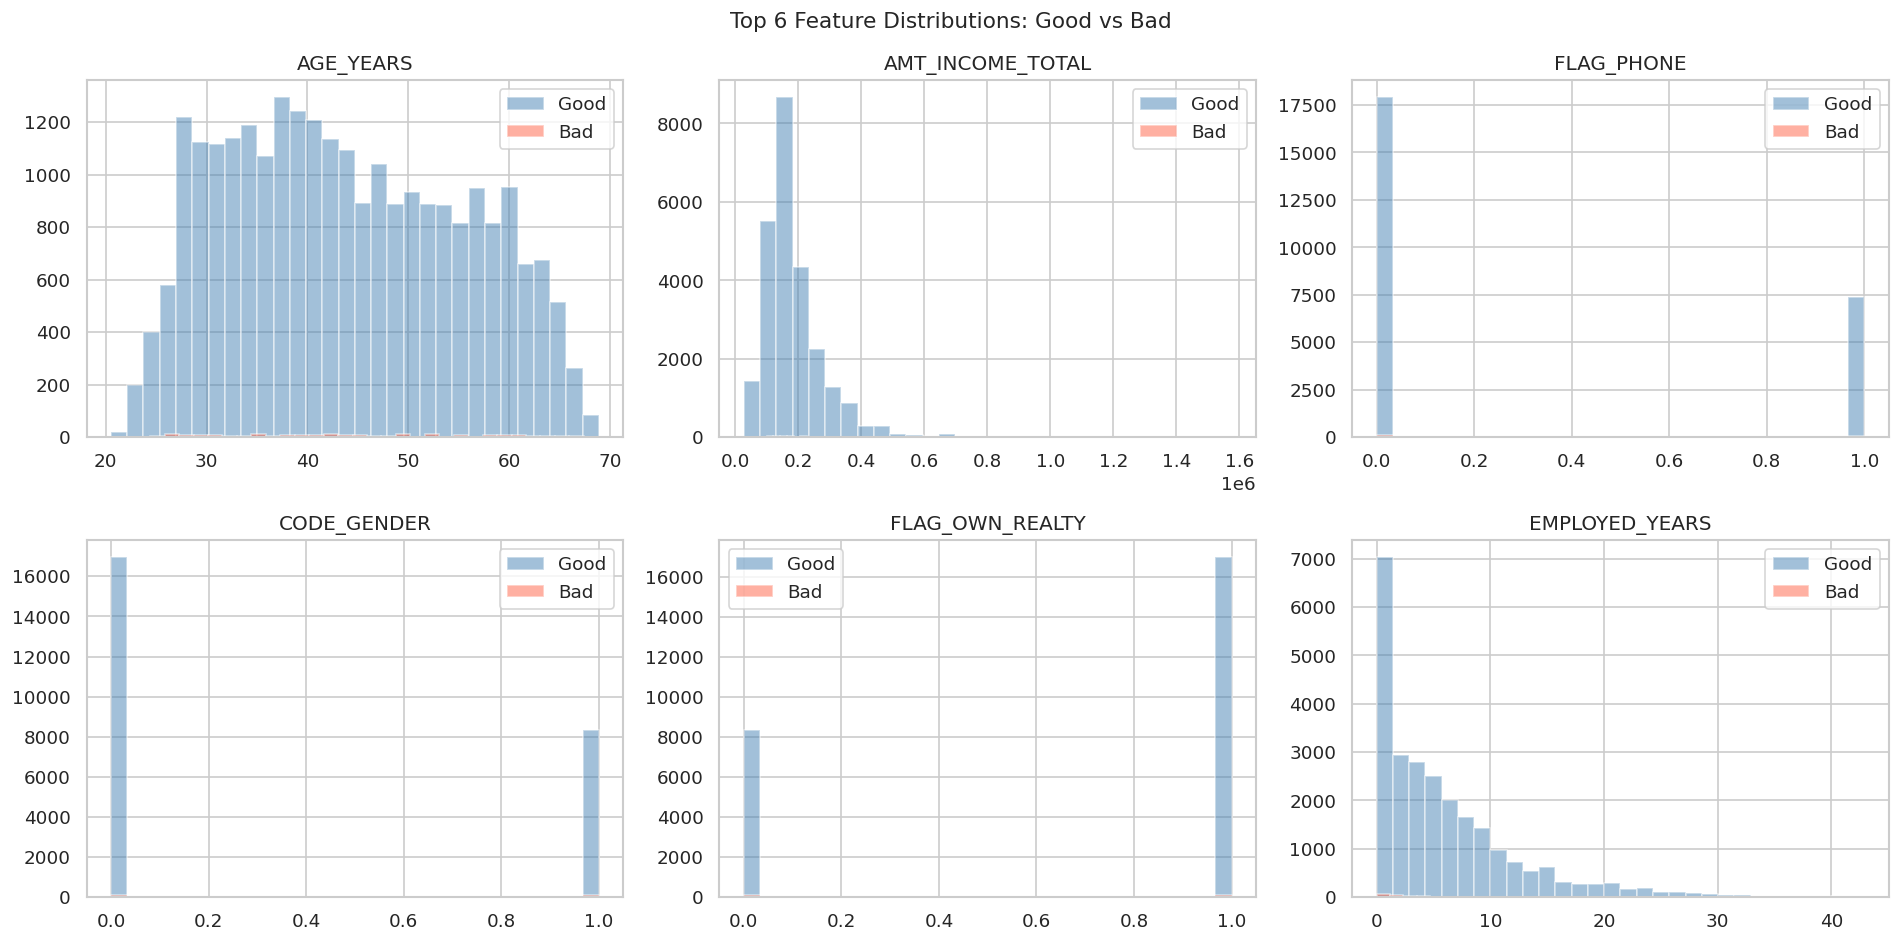

In [ ]:
from scipy import stats
import seaborn as sns

# 1. Feature separation
separation = []
for col in X.columns:
    good = df_train[df_train['TARGET'] == 0][col]
    bad  = df_train[df_train['TARGET'] == 1][col]
    stat, p = stats.mannwhitneyu(good, bad, alternative='two-sided')
    effect  = abs(good.mean() - bad.mean()) / (df_train[col].std() + 1e-9)
    separation.append({
        'feature'    : col,
        'good_mean'  : round(good.mean(), 4),
        'bad_mean'   : round(bad.mean(), 4),
        'effect_size': round(effect, 4),
        'p_value'    : round(p, 6)
    })

sep_df = pd.DataFrame(separation).sort_values('effect_size', ascending=False)
print('=== Feature Separation (Good vs Bad) ===\n')
print(sep_df.to_string(index=False))

# 2. Correlation with target
correlations = df_train.corr()['TARGET'].drop('TARGET').abs().sort_values(ascending=False)
print('\n=== Absolute Correlation with TARGET ===')
print(correlations.round(4).to_string())

# 3. RF feature importance
feat_imp = pd.DataFrame({
    'feature'   : X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print('\n=== RF Feature Importance ===')
print(feat_imp.round(4).to_string(index=False))

# 4. Plots
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=feat_imp, x='importance', y='feature', ax=ax, palette='viridis')
ax.set_title('RF Feature Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

fig2, axes2 = plt.subplots(2, 3, figsize=(16, 8))
for ax, feat in zip(axes2.flatten(), feat_imp['feature'].head(6).tolist()):
    df_train[df_train['TARGET']==0][feat].hist(alpha=0.5, label='Good', bins=30, ax=ax, color='steelblue')
    df_train[df_train['TARGET']==1][feat].hist(alpha=0.5, label='Bad',  bins=30, ax=ax, color='tomato')
    ax.set_title(feat)
    ax.legend()
fig2.suptitle('Top 6 Feature Distributions: Good vs Bad', fontsize=13)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Final test set evaluation ─────────────────────────────────────────────────
print('=== FINAL TEST SET PERFORMANCE ===')
results['RF_final'] = evaluate_model(rf, X_test_sc, y_test,
                                      'Random Forest FINAL', threshold=0.44)

=== FINAL TEST SET PERFORMANCE ===

  Random Forest FINAL
              precision    recall  f1-score   support

        Good       0.99      0.99      0.99      5424
         Bad       0.30      0.31      0.30        45

    accuracy                           0.99      5469
   macro avg       0.65      0.65      0.65      5469
weighted avg       0.99      0.99      0.99      5469

  ROC-AUC : 0.7950


In [ ]:
print('=== Full dataset class distribution ===')
print(y.value_counts())
print(f'\nTotal records : {len(y)}')
print(f'Total Bad     : {(y==1).sum()}')
print(f'Total Good    : {(y==0).sum()}')
print(f'Default rate  : {(y==1).sum()/len(y)*100:.2f}%')

=== Full dataset class distribution ===
TARGET
0    36155
1      302
Name: count, dtype: int64

Total records : 36457
Total Bad     : 302
Total Good    : 36155
Default rate  : 0.83%


=== Optimal Thresholds ===

Logistic Regression
  Best threshold : 0.429
  Precision      : 0.012
  Recall         : 0.739
  F2 score  : 0.055

SVM (RBF Kernel)
  Best threshold : 0.259
  Precision      : 0.048
  Recall         : 0.304
  F2 score  : 0.147

=== FINAL TEST SET PERFORMANCE ===


  Logistic Regression FINAL
              precision    recall  f1-score   support

        Good       0.99      0.46      0.63      5424
         Bad       0.01      0.71      0.02        45

    accuracy                           0.46      5469
   macro avg       0.50      0.59      0.33      5469
weighted avg       0.99      0.46      0.62      5469

  ROC-AUC : 0.6474

  SVM (RBF Kernel) FINAL
              precision    recall  f1-score   support

        Good       0.99      0.96      0.98      5424
         Bad       0.06      0.31      0.10        45

    accuracy                           0.95      5469
   macro avg       0.53      0.63      0.54      5469
weighted avg       0.99      0.95 

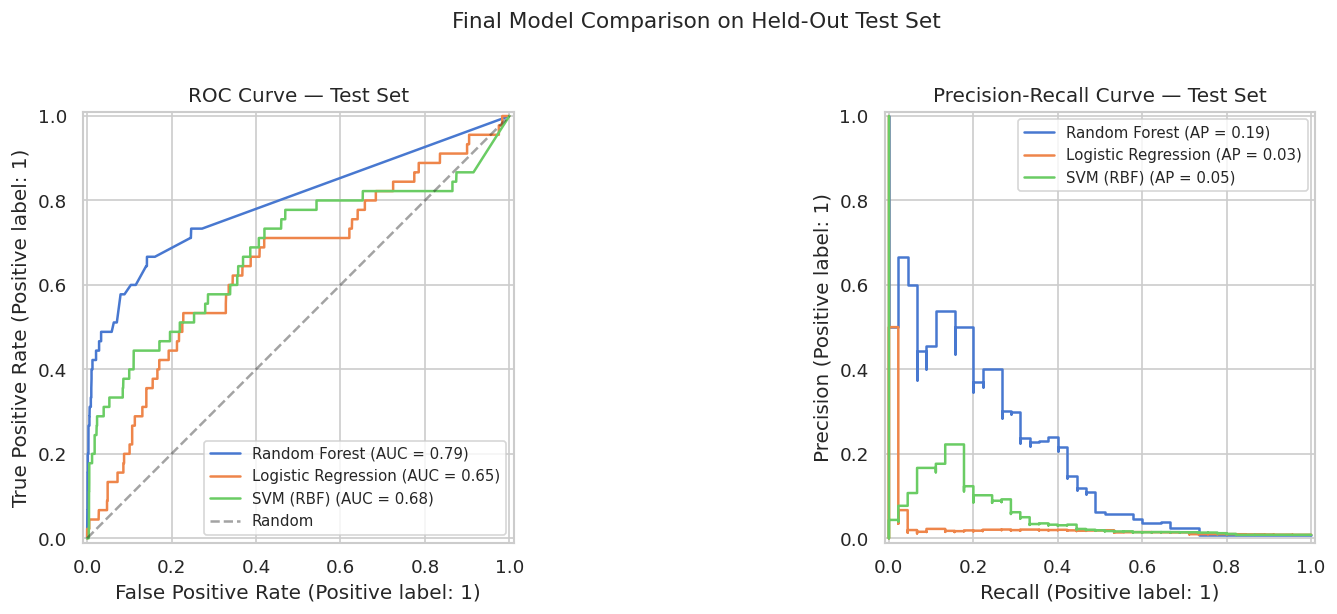

In [ ]:
# ── Self-contained final evaluation: LR + SVM ─────────────────────────────────
from sklearn.metrics import (precision_recall_curve, precision_score,
                             recall_score, f1_score, RocCurveDisplay,
                             PrecisionRecallDisplay)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Redefine find_best_threshold ──────────────────────────────────────────────
def find_best_threshold(y_true, y_prob, model_name, beta=2):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
    fbeta = ((1 + beta**2) * (precisions * recalls) /
             (beta**2 * precisions + recalls + 1e-9))
    best_idx   = np.argmax(fbeta)
    best_thresh = thresholds[best_idx]
    print(f'{model_name}')
    print(f'  Best threshold : {best_thresh:.3f}')
    print(f'  Precision      : {precisions[best_idx]:.3f}')
    print(f'  Recall         : {recalls[best_idx]:.3f}')
    print(f'  F{beta} score  : {fbeta[best_idx]:.3f}\n')
    return best_thresh

# ── Find optimal thresholds on val set ───────────────────────────────────────
print('=== Optimal Thresholds ===\n')
lr_thresh  = find_best_threshold(y_val, results['LR']['y_prob'],  'Logistic Regression', beta=2)
svm_thresh = find_best_threshold(y_val, results['SVM']['y_prob'], 'SVM (RBF Kernel)',    beta=2)

# ── Final test set evaluation ─────────────────────────────────────────────────
print('=== FINAL TEST SET PERFORMANCE ===\n')
results['LR_final']  = evaluate_model(lr,  X_test_sc, y_test,
                                      'Logistic Regression FINAL', threshold=lr_thresh)
results['SVM_final'] = evaluate_model(svm, X_test_sc, y_test,
                                      'SVM (RBF Kernel) FINAL',    threshold=svm_thresh)

# ── Comparison table ──────────────────────────────────────────────────────────
print('\n' + '='*65)
print('  FINAL MODEL COMPARISON — TEST SET')
print('='*65)

models_to_compare = {
    'Random Forest'       : (results['RF_final'],  0.44),
    'Logistic Regression' : (results['LR_final'],  lr_thresh),
    'SVM (RBF)'           : (results['SVM_final'], svm_thresh),
}

rows = []
for name, (res, thresh) in models_to_compare.items():
    y_pred = res['y_pred']
    rows.append({
        'Model'          : name,
        'Threshold'      : round(thresh, 2),
        'Precision (Bad)': round(precision_score(y_test, y_pred, pos_label=1, zero_division=0), 2),
        'Recall (Bad)'   : round(recall_score(y_test, y_pred,    pos_label=1), 2),
        'F1 (Bad)'       : round(f1_score(y_test, y_pred,        pos_label=1), 2),
        'ROC-AUC'        : round(res['auc'], 4),
    })

comparison_df = pd.DataFrame(rows).set_index('Model')
print(comparison_df.to_string())

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_map = {
    'Random Forest'       : results['RF_final'],
    'Logistic Regression' : results['LR_final'],
    'SVM (RBF)'           : results['SVM_final'],
}

for name, res in model_map.items():
    RocCurveDisplay.from_predictions(y_test, res['y_prob'], name=name, ax=axes[0])
    PrecisionRecallDisplay.from_predictions(y_test, res['y_prob'], name=name, ax=axes[1])

axes[0].plot([0,1],[0,1],'k--', alpha=0.4, label='Random')
axes[0].set_title('ROC Curve — Test Set')
axes[1].set_title('Precision-Recall Curve — Test Set')

for ax in axes:
    ax.legend(fontsize=9)

plt.suptitle('Final Model Comparison on Held-Out Test Set', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('final_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()